In [1]:
import torch
import os
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from torch.utils.data import Dataset, DataLoader
from torch.optim import optimizer

UPSAMPLE_FACTOR = 4  # 分辨率放大倍数（例如 4 代表将1个采样点细分为4份）
CRITICAL_DIST = 5  # 触发“退火收缩”的临界距离（相距小于5个采样点时缩小高斯峰）


In [2]:
def generate_simulation_data(batch_size, window_size=4000, max_delay=100, max_points=2):
    """
    生成模拟的 MZ-Sagnac 多点重叠扰动数据及一维高斯热力图标签
    采样率参考 5 MSa/s [cite: 825]。
    """
    X = torch.zeros(batch_size, 2, window_size)
    # 标签热力图长度升级为高分辨率网格
    up_length = int(2 * max_delay * UPSAMPLE_FACTOR + 1)
    Y_heatmap = torch.zeros(batch_size, up_length)


    t = np.arange(window_size)

    for b in range(batch_size):
        num_points = max_points
        # num_points = int(np.random.randint(1, max_points + 1))
        x_signal = np.zeros(window_size)
        y_signal = np.zeros(window_size)

        # 先生成所有点的确切延迟，便于计算相互距离
        delays = []
        onsets = []
        for p in range(num_points):
            delays.append(np.random.randint(-max_delay + 10, max_delay - 10))
            onsets.append(np.random.randint(100, window_size - 1000))

        for i in range(num_points):
            delay = delays[i]
            onset = onsets[i]

            # 多频混合瞬态衰减信号
            A = np.random.uniform(0.5, 1.5)
            alpha = np.random.uniform(0.005, 0.01)
            freqs = [np.random.uniform(0.005,0.01), np.random.uniform(0.01,0.02)]

            # 构造 x(t)
            x_component = np.zeros(window_size)
            envelope = A * np.exp(-alpha * (t[onset:] - onset))
            for f in freqs:
                x_component[onset:] += envelope * np.sin(2 * np.pi * f * (t[onset:] - onset))

            # 构造 y(t) = x(t - delay)
            y_component = np.roll(x_component, delay)

            x_signal += x_component
            y_signal += y_component


            # 👑 方案三：退火收缩高斯目标逻辑
            # ==========================================
            # 基础 Sigma：因为网格放大了，基础 Sigma 也要同比例放大
            base_sigma = 2.0 * UPSAMPLE_FACTOR
            current_sigma = base_sigma

            # 检查当前点与其他点的距离
            for j in range(num_points):
                if i != j:
                    dist = abs(delay - delays[j])
                    if dist <= CRITICAL_DIST:
                        # 距离极近，强行将 Sigma 缩小至原来的 1/4 (针状峰)
                        current_sigma = min(current_sigma, 0.5 * UPSAMPLE_FACTOR)

            # 在对应延迟位置渲染一维高斯分布 (Sigma = 2.0)
            # 避免直接回归造成的偏移，利用高斯分布引导网络学习平滑特征
            # 将粗糙的 delay 映射到高分辨率网格的确切像素索引
            center_idx = (delay + max_delay) * UPSAMPLE_FACTOR
            x_grid = np.arange(up_length)

            gaussian = np.exp(-((x_grid - center_idx) ** 2) / (2 * current_sigma ** 2))
            Y_heatmap[b] = torch.max(Y_heatmap[b], torch.tensor(gaussian, dtype=torch.float32))

        # 添加高斯白噪声
        X[b, 0, :] = torch.tensor(x_signal) + torch.randn(window_size) * 0.001
        X[b, 1, :] = torch.tensor(y_signal) + torch.randn(window_size) * 0.001

    return X, Y_heatmap

In [3]:

class DelayEstimationDataset(Dataset):
    def __init__(self, num_samples, window_size, max_delay,max_points = 1, mode='train'):
        self.num_samples = num_samples
        self.window_size = window_size
        self.max_delay = max_delay
        self.max_points = max_points
        self.mode = mode

        # 预生成所有数据，避免训练时动态生成导致的IO瓶颈
        self.X,self.Y_heatmap = generate_simulation_data(num_samples, window_size, max_delay, max_points)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        val = self.X[idx]
        target = self.Y_heatmap[idx]
        return val,target


class NonCausalDilatedConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, dilation=1):
        super().__init__()
        # 严格计算对称 Padding，确保非因果性（零相位偏移）
        pad = dilation * (kernel_size - 1) // 2
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size,padding=pad,
                              padding_mode='zeros', dilation=dilation, bias=False)
        self.bn = nn.InstanceNorm1d(out_channels,affine=True)
        self.relu = nn.PReLU()

    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))



class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.PReLU(),
            nn.Linear(channels // reduction, channels, bias=False),
            # nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)


class OptimizedFeatureCorrelationLayer(nn.Module):
    def __init__(self, max_delay):
        super().__init__()
        self.max_delay = max_delay

    def forward(self, f_x, f_y):
        """
        利用 F.conv1d 和 Grouped Convolution 极致优化计算图的互相关
        输入维度: f_x, f_y -> [B, C, L]
        输出维度: [B, C, 2*max_delay + 1]
        """
        B, C, L = f_x.size()
     # 1. 掐头去尾：从 f_x 中切出绝对安全的“中心有效区域”
        # 我们切掉两端长度为 max_delay 的特征。这部分特征被补零严重污染。
        # 切割后，f_x_center 的长度为 L - 2 * max_delay
        crop_len = self.max_delay
        f_x_center = f_x[:, :, crop_len : L - crop_len]

        # 2. 零均值化 (抗 DC 偏置)
        # 注意：必须在切割后独立计算均值，防止边缘污染整体均值
        f_x_center = f_x_center - f_x_center.mean(dim=-1, keepdim=True)
        f_y = f_y - f_y.mean(dim=-1, keepdim=True)

        # 3. 余弦归一化 (转换为皮尔逊相关系数)
        f_x_center = F.normalize(f_x_center, p=2, dim=2)
        f_y = F.normalize(f_y, p=2, dim=2)

        # 4. 纯 Valid 滑动匹配 (摒弃所有人为的 Padding)
        # 将 f_y 作为被滑动的长画布 (Length = L)
        f_y_reshaped = f_y.view(1, B * C, L)

        # 将 f_x_center 作为滑动模板 (Length = L - 2*max_delay)
        f_x_center_reshaped = f_x_center.view(B * C, 1, L - 2 * crop_len)

        # F.conv1d 默认 padding=0 (即 Valid 模式)
        # 输出长度计算公式: L_{out} = L_{in} - L_{kernel} + 1
        # L_{out} = L - (L - 2*max_delay) + 1 = 2*max_delay + 1
        # 这完美对应了从 -max_delay 到 +max_delay 的 2*max_delay + 1 个延迟点！
        corr = F.conv1d(f_y_reshaped, f_x_center_reshaped, groups=B * C)

        # # 4. 恢复输出维度: [1, B*C, 2*max_delay + 1] -> [B, C, 2*max_delay + 1]
        corr = corr.view(B, C, -1)

        return corr


class DC_SWCNet(nn.Module):
    def __init__(self, max_delay=100, feature_dim=32):
        super().__init__()
        self.max_delay = max_delay
        # 目标上采样长度计算公式，确保 0 点绝对居中
        self.target_length = int(2 * max_delay * UPSAMPLE_FACTOR + 1)

        # 将双通道输入分离，但在同一骨干网络中共享权重提取特征


        dilations = [1, 2, 4,8]

        # 使用 ModuleList 动态创建不同深度的 Block
        self.feature_extractor = nn.ModuleList()
        for i, d in enumerate(dilations):
            # 第一个 block 输入通道为 1，后续 block 输入通道为 feature_dim
            in_channels = 1 if i == 0 else feature_dim
            self.feature_extractor.append(
                NonCausalDilatedConv1d(in_channels, feature_dim, kernel_size=5, dilation=d)
            )
        self.channel_attention = ChannelAttention(feature_dim)
        self.correlation_layer = OptimizedFeatureCorrelationLayer(max_delay)

        # 1D 预测头：将多通道相关性压缩为一维最终时延热力图
        self.prediction_head = nn.Sequential(
            nn.Conv1d(feature_dim * len(dilations), feature_dim, kernel_size=3, padding=1),
            nn.PReLU(),
            nn.Upsample(size=self.target_length, mode='linear', align_corners=True),
            nn.Conv1d(feature_dim, 16, kernel_size=3, padding=1),
            nn.PReLU(),
            nn.Conv1d(16, 1, kernel_size=1),
        )

    def forward(self, x):
        # x 维度: [B, 2, L]
        x_ch = x[:, 0:1, :]
        y_ch = x[:, 1:2, :]

        corr_list = []

        # 循环提取多尺度特征并计算互相关
        # 注意：这里保留了原来的串行依赖结构（f2依赖f1，f3依赖f2）
        curr_x = x_ch
        curr_y = y_ch

        for block in self.feature_extractor:
            # 提取当前尺度的特征
            curr_x = block(curr_x)
            curr_y = block(curr_y)

            # 计算当前尺度的互相关
            corr = self.correlation_layer(curr_x, curr_y)
            corr_list.append(corr)

        # 将多尺度相关性矩阵在 Channel 维度拼接
        # 维度变为: [B, C * num_scales, 2*max_delay*UPSAMPLE_FACTOR + 1]
        corr_fused = torch.cat(corr_list, dim=1)
        # heatmap shape 变为: [B, 2*max_delay*UPSAMPLE_FACTOR + 1]
        heatmap = self.prediction_head(corr_fused).squeeze(1)

        return heatmap

class WeightedGaussianMSELoss(nn.Module):
    def __init__(self, peak_weight=10.0, bg_weight=1.0):
        super().__init__()
        self.peak_weight = peak_weight
        self.bg_weight = bg_weight

    def forward(self, pred, target):
        # target 是真实的 1D 高斯热力图 (0 到 1 之间)
        # 我们利用 target 本身的值来生成权重图
        # 当 target 接近 1 时，权重为 peak_weight；当 target 为 0 时，权重为 bg_weight
        weight_map = self.bg_weight + target * (self.peak_weight - self.bg_weight)

        # 计算加权的 MSE
        squared_error = (pred - target) ** 2
        weighted_loss = weight_map * squared_error

        return torch.sum(weighted_loss)


def extract_peaks_from_heatmap(heatmap, max_delay, threshold=0.4):
    """
    从高分辨率一维热力图中提取物理时延（天然支持亚像素精度）
    """
    heatmap_np = heatmap.detach().cpu().numpy()
    batch_peaks = []

    # 高分辨率网格下，寻找峰值的距离要求也需相应放大
    min_distance = 2

    for i in range(heatmap_np.shape[0]):
        hm = heatmap_np[i]
        peaks, _ = find_peaks(hm, height=threshold, distance=min_distance)

        sub_pixel_peaks = []
        for p in peaks:
            # 依然保留抛物线二次插值，精益求精
            if 0 < p < len(hm) - 1:
                alpha = hm[p - 1]
                beta = hm[p]
                gamma = hm[p + 1]
                offset = 0.5 * (alpha - gamma) / (alpha - 2 * beta + gamma + 1e-6)
                exact_p_up = p + offset
            else:
                exact_p_up = p

            # 👑 高分辨率解码公式：
            # 先除以放大倍数转回原始尺度坐标，再减去 max_delay
            actual_delay = (exact_p_up / UPSAMPLE_FACTOR) - max_delay
            sub_pixel_peaks.append(actual_delay)

        batch_peaks.append(sub_pixel_peaks)

    return batch_peaks

# def extract_peaks_from_heatmap(heatmap, max_delay, threshold=0.5):
#     """
#     从一维热力图中提取时延峰值（支持多点、亚像素）
#     """
#     heatmap_np = heatmap.detach().cpu().numpy()
#     batch_peaks = []
#
#     for i in range(heatmap_np.shape[0]):
#         hm = heatmap_np[i]
#         # 寻找局部峰值 (一维 NMS)
#         peaks, properties = find_peaks(hm, height=threshold, distance=10)
#
#         sub_pixel_peaks = []
#         for p in peaks:
#             # 二次插值 (Quadratic Interpolation) 获取亚像素精度
#             if 0 < p < len(hm) - 1:
#                 alpha = hm[p - 1]
#                 beta = hm[p]
#                 gamma = hm[p + 1]
#                 # 抛物线顶点偏移量公式
#                 offset = 0.5 * (alpha - gamma) / (alpha - 2 * beta + gamma)
#                 exact_p = p + offset
#             else:
#                 exact_p = p
#
#             # 还原为真实延迟时间 (-max_delay 到 +max_delay)
#             actual_delay = exact_p - max_delay
#             sub_pixel_peaks.append(actual_delay)
#
#         batch_peaks.append(sub_pixel_peaks)
#         # print(batch_peaks)
#
#     return batch_peaks


def train_and_validate(epochs):
    # 超参数配置
    batch_size = 64
    max_delay = 100
    window_size = 4000
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = DC_SWCNet(max_delay=max_delay).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=8e-4, weight_decay=1e-5)

    # 采用高斯平滑后的 MSE Loss
    criterion = WeightedGaussianMSELoss()

    # 划分数据集 (80% 训练集, 20% 测试集)
    train_dataset = DelayEstimationDataset(num_samples=8000, window_size=window_size, max_delay=max_delay)
    test_dataset = DelayEstimationDataset(num_samples=2000, window_size=window_size, max_delay=max_delay)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # 初始化模型、优化器
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


    # 训练循环 (带进度条)
    train_losses, test_losses = [], []
    print(f"Training on: {device}")

    for epoch in range(epochs):
        # --- 训练阶段 ---
        model.train()
        running_train_loss = 0.0
        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=True)
        for batch_x, batch_y in train_pbar:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()
            train_pbar.set_postfix({'Loss': f"{loss.item():.4f}"})

        avg_train_loss = running_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # --- 测试阶段 ---
        model.eval()
        running_test_loss = 0.0
        with torch.no_grad():
            test_pbar = tqdm(test_loader, desc=f"Epoch {epoch+1}/{epochs} [Test] ", leave=True)
            for batch_x, batch_y in test_pbar:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                loss = criterion(outputs, batch_y)
                running_test_loss += loss.item()

        avg_test_loss = running_test_loss / len(test_loader)
        test_losses.append(avg_test_loss)

        print(f">> Epoch {epoch+1} Summary | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}\n")
                    # ... 前面的训练循环代码 ...

        if epoch>=10 and (epoch + 1) % 2 == 0:
            # --- 验证阶段 ---
            model.eval()
            with torch.no_grad():
                val_inputs, val_targets = generate_simulation_data(4, window_size, max_delay)
                val_inputs = val_inputs.to(device)
                val_outputs = model(val_inputs)

                print(val_targets.shape)
                print(val_outputs.shape)

                print("验证批次时延预测结果:")
                predicted_peaks = extract_peaks_from_heatmap(val_outputs, max_delay, threshold=0.4)
                true_peaks = extract_peaks_from_heatmap(val_targets, max_delay, threshold=0.4)

                for b in range(4):
                    print(f"  样本 {b}:")
                    print(f"    真实时延 : {['{:.2f}'.format(p) for p in true_peaks[b]]}")
                    print(f"    预测时延 : {['{:.2f}'.format(p) for p in predicted_peaks[b]]}")

                # ==========================================
                # --- 新增：一维热力图输出可视化 ---
                # ==========================================
                # 将张量转移到 CPU 并转换为 NumPy 数组
                targets_np = val_targets.cpu().numpy()
                outputs_np = val_outputs.cpu().numpy()

                up_length = int(2 * max_delay * UPSAMPLE_FACTOR + 1)
                # 使用 linspace 将 [-max_delay, max_delay] 的物理区间均匀切分为 up_length 份
                x_axis = np.linspace(-max_delay, max_delay, up_length)

                # 创建 4 个子图，呈垂直排列
                fig, axes = plt.subplots(4, 1, figsize=(10, 12))
                fig.subplots_adjust(hspace=0.5)  # 增加子图之间的垂直间距

                for i in range(4):
                    # 绘制真实的 Target 高斯曲线 (绿色虚线)
                    axes[i].plot(x_axis, targets_np[i], label='Target (Ground Truth)', color='green',
                                 linestyle='--', linewidth=2)

                    # 绘制网络的 Output 预测曲线 (红色实线)
                    axes[i].plot(x_axis, outputs_np[i], label='Prediction (Output)', color='red', alpha=0.8,
                                 linewidth=2)

                    # 用垂直点划线标出提取到的确切峰值位置
                    for tp in true_peaks[i]:
                        axes[i].axvline(x=tp, color='green', linestyle=':', alpha=0.6)
                    for pp in predicted_peaks[i]:
                        axes[i].axvline(x=pp, color='red', linestyle=':', alpha=0.6)

                    # 设置图表格式
                    axes[i].set_title(f"Sample {i} - Heatmap Comparison")
                    axes[i].set_xlabel("Time Delay (Sampling Points)")
                    axes[i].set_ylabel("Probability Intensity")
                    axes[i].legend(loc="upper right")
                    axes[i].grid(True, alpha=0.3)

                    # 固定 Y 轴范围，防止由于预测值过小导致坐标轴自动缩放引发的视觉误判
                    axes[i].set_ylim(-0.1, 1.2)

                plt.show()

                # 释放内存，防止在长时间训练中因为重复创建绘图对象导致 OOM
                plt.close(fig)

                print("-" * 40)

    # 打包需要保存的所有关键组件
    checkpoint = {
        'epoch': epoch,                        # 当前轮次
        'model_state_dict': model.state_dict(), # 模型权重
        'optimizer_state_dict': optimizer.state_dict(), # 优化器状态（动量等）
        'loss': loss,                          # 当前损失值
    }

    # 保存断点文件
    BASE_DIR = './model'
    os.makedirs(BASE_DIR, exist_ok=True)
    MODEL_SAVE_PATH = os.path.join(BASE_DIR, f'checkpoint_epoch_{epoch}.pth')


    torch.save(checkpoint, MODEL_SAVE_PATH)
    return MODEL_SAVE_PATH


def continue_training(MODEL_SAVE_PATH, total_epochs):
    # 5. 继续训练循环
    batch_size = 64
    max_delay = 100
    window_size = 4000
    epochs = total_epochs
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = DC_SWCNet(max_delay=max_delay).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

    # 采用高斯平滑后的 MSE Loss
    criterion = WeightedGaussianMSELoss()

    # 划分数据集 (80% 训练集, 20% 测试集)
    train_dataset = DelayEstimationDataset(num_samples=8000, window_size=window_size, max_delay=max_delay)
    test_dataset = DelayEstimationDataset(num_samples=2000, window_size=window_size, max_delay=max_delay)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # 初始化模型、优化器
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


    # 训练循环 (带进度条)
    train_losses, test_losses = [], []
    print(f"Training on: {device}")

    # 1. 加载断点文件（使用 map_location 确保在不同设备间兼容）
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    checkpoint = torch.load(MODEL_SAVE_PATH, map_location=device)

    # 2. 按顺序恢复状态
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])


    # 4. 获取断点时的轮次，从下一个轮次继续
    start_epoch = checkpoint['epoch'] + 1
    print(f"从第 {start_epoch} 轮继续训练...")


    for epoch in range(start_epoch, total_epochs):
        # --- 训练阶段 ---
        model.train()
        running_train_loss = 0.0
        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=True)
        for batch_x, batch_y in train_pbar:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()
            train_pbar.set_postfix({'Loss': f"{loss.item():.4f}"})

        avg_train_loss = running_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # --- 测试阶段 ---
        model.eval()
        running_test_loss = 0.0
        with torch.no_grad():
            test_pbar = tqdm(test_loader, desc=f"Epoch {epoch+1}/{epochs} [Test] ", leave=True)
            for batch_x, batch_y in test_pbar:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                loss = criterion(outputs, batch_y)
                running_test_loss += loss.item()

        avg_test_loss = running_test_loss / len(test_loader)
        test_losses.append(avg_test_loss)

        print(f">> Epoch {epoch+1} Summary | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}\n")
                    # ... 前面的训练循环代码 ...

        if (epoch + 1) % 4 == 0:
            # --- 验证阶段 ---
            model.eval()
            with torch.no_grad():
                val_inputs, val_targets = generate_simulation_data(4, window_size, max_delay)
                val_inputs = val_inputs.to(device)
                val_outputs = model(val_inputs)

                print("验证批次时延预测结果:")
                predicted_peaks = extract_peaks_from_heatmap(val_outputs, max_delay, threshold=0.4)
                true_peaks = extract_peaks_from_heatmap(val_targets, max_delay, threshold=0.4)

                for b in range(4):
                    print(f"  样本 {b}:")
                    print(f"    真实时延 : {['{:.2f}'.format(p) for p in true_peaks[b]]}")
                    print(f"    预测时延 : {['{:.2f}'.format(p) for p in predicted_peaks[b]]}")

                # ==========================================
                # --- 新增：一维热力图输出可视化 ---
                # ==========================================
                # 将张量转移到 CPU 并转换为 NumPy 数组
                targets_np = val_targets.cpu().numpy()
                outputs_np = val_outputs.cpu().numpy()

                # 构建 X 轴坐标 (从 -max_delay 到 +max_delay)
                x_axis = np.arange(-max_delay, max_delay + 1)

                # 创建 4 个子图，呈垂直排列
                fig, axes = plt.subplots(4, 1, figsize=(10, 12))
                fig.subplots_adjust(hspace=0.5)  # 增加子图之间的垂直间距

                for i in range(4):
                    # 绘制真实的 Target 高斯曲线 (绿色虚线)
                    axes[i].plot(x_axis, targets_np[i], label='Target (Ground Truth)', color='green',
                                 linestyle='--', linewidth=2)

                    # 绘制网络的 Output 预测曲线 (红色实线)
                    axes[i].plot(x_axis, outputs_np[i], label='Prediction (Output)', color='red', alpha=0.8,
                                 linewidth=2)

                    # 用垂直点划线标出提取到的确切峰值位置
                    for tp in true_peaks[i]:
                        axes[i].axvline(x=tp, color='green', linestyle=':', alpha=0.6)
                    for pp in predicted_peaks[i]:
                        axes[i].axvline(x=pp, color='red', linestyle=':', alpha=0.6)

                    # 设置图表格式
                    axes[i].set_title(f"Sample {i} - Heatmap Comparison")
                    axes[i].set_xlabel("Time Delay (Sampling Points)")
                    axes[i].set_ylabel("Probability Intensity")
                    axes[i].legend(loc="upper right")
                    axes[i].grid(True, alpha=0.3)

                    # 固定 Y 轴范围，防止由于预测值过小导致坐标轴自动缩放引发的视觉误判
                    axes[i].set_ylim(-0.1, 1.2)

                plt.show()

                # 释放内存，防止在长时间训练中因为重复创建绘图对象导致 OOM
                plt.close(fig)

                print("-" * 40)

    # 打包需要保存的所有关键组件
    checkpoint = {
        'epoch': epoch,                        # 当前轮次
        'model_state_dict': model.state_dict(), # 模型权重
        'optimizer_state_dict': optimizer.state_dict(), # 优化器状态（动量等）
        'loss': loss,                          # 当前损失值
    }

    # 保存断点文件
    BASE_DIR = './model'
    os.makedirs(BASE_DIR, exist_ok=True)
    MODEL_SAVE_PATH = os.path.join(BASE_DIR, f'checkpoint_epoch_{epoch}.pth')


    torch.save(checkpoint, MODEL_SAVE_PATH)
    return MODEL_SAVE_PATH



Training on: cuda


Epoch 1/20 [Train]:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 1/20 [Test] :   0%|          | 0/32 [00:00<?, ?it/s]

>> Epoch 1 Summary | Train Loss: 735.8892 | Test Loss: 23.1951



Epoch 2/20 [Train]:   0%|          | 0/125 [00:00<?, ?it/s]

...

Epoch 11/20 [Test] :   0%|          | 0/32 [00:00<?, ?it/s]

>> Epoch 11 Summary | Train Loss: 0.9249 | Test Loss: 0.7557



Epoch 12/20 [Train]:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 12/20 [Test] :   0%|          | 0/32 [00:00<?, ?it/s]

>> Epoch 12 Summary | Train Loss: 0.8120 | Test Loss: 0.6319

torch.Size([4, 801])
torch.Size([4, 801])
验证批次时延预测结果:
  样本 0:
    真实时延 : ['-82.00', '2.00']
    预测时延 : ['2.03']
  样本 1:
    真实时延 : ['-46.00', '-44.00']
    预测时延 : ['-44.28']
  样本 2:
    真实时延 : ['14.00', '62.00']
    预测时延 : ['62.09']
  样本 3:
    真实时延 : ['12.00', '25.00']
    预测时延 : ['12.02']


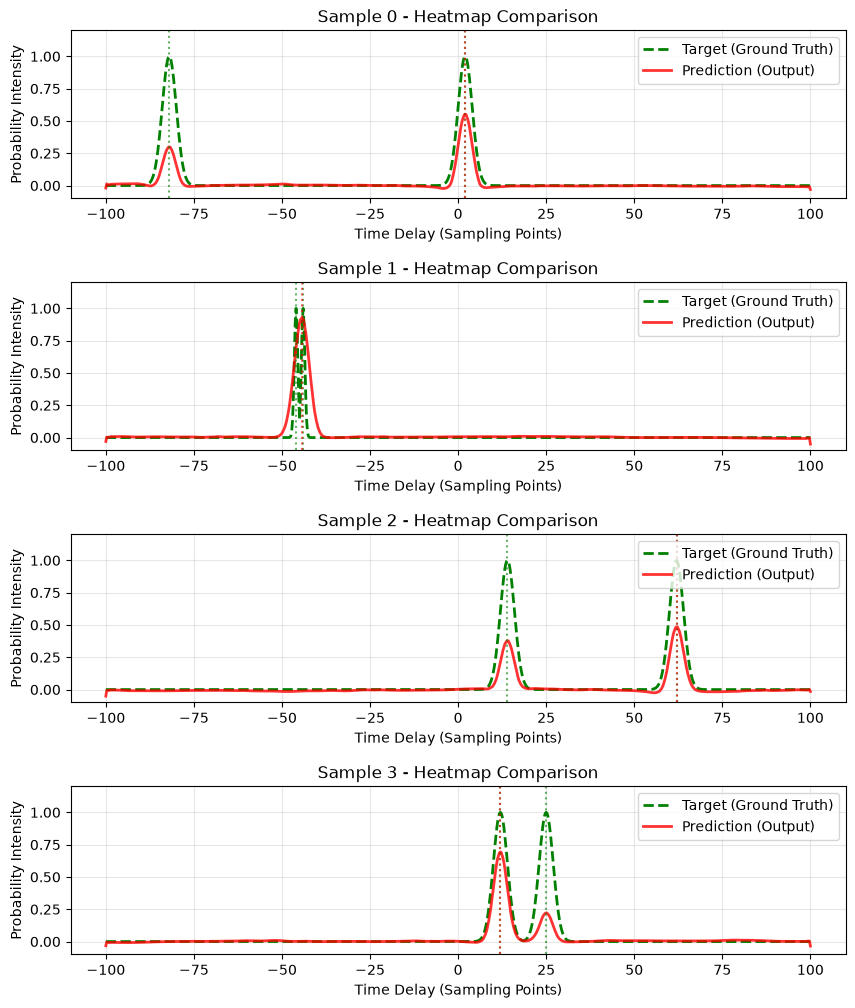

----------------------------------------


Epoch 13/20 [Train]:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 13/20 [Test] :   0%|          | 0/32 [00:00<?, ?it/s]

>> Epoch 13 Summary | Train Loss: 0.8173 | Test Loss: 0.7844



Epoch 14/20 [Train]:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 14/20 [Test] :   0%|          | 0/32 [00:00<?, ?it/s]

>> Epoch 14 Summary | Train Loss: 0.6720 | Test Loss: 0.6110

torch.Size([4, 801])
torch.Size([4, 801])
验证批次时延预测结果:
  样本 0:
    真实时延 : ['-65.00', '-9.00']
    预测时延 : ['-64.93']
  样本 1:
    真实时延 : ['-63.00', '-9.00']
    预测时延 : ['-62.98']
  样本 2:
    真实时延 : ['-53.00', '-37.00']
    预测时延 : ['-37.03']
  样本 3:
    真实时延 : ['-74.00', '26.00']
    预测时延 : ['-73.97']


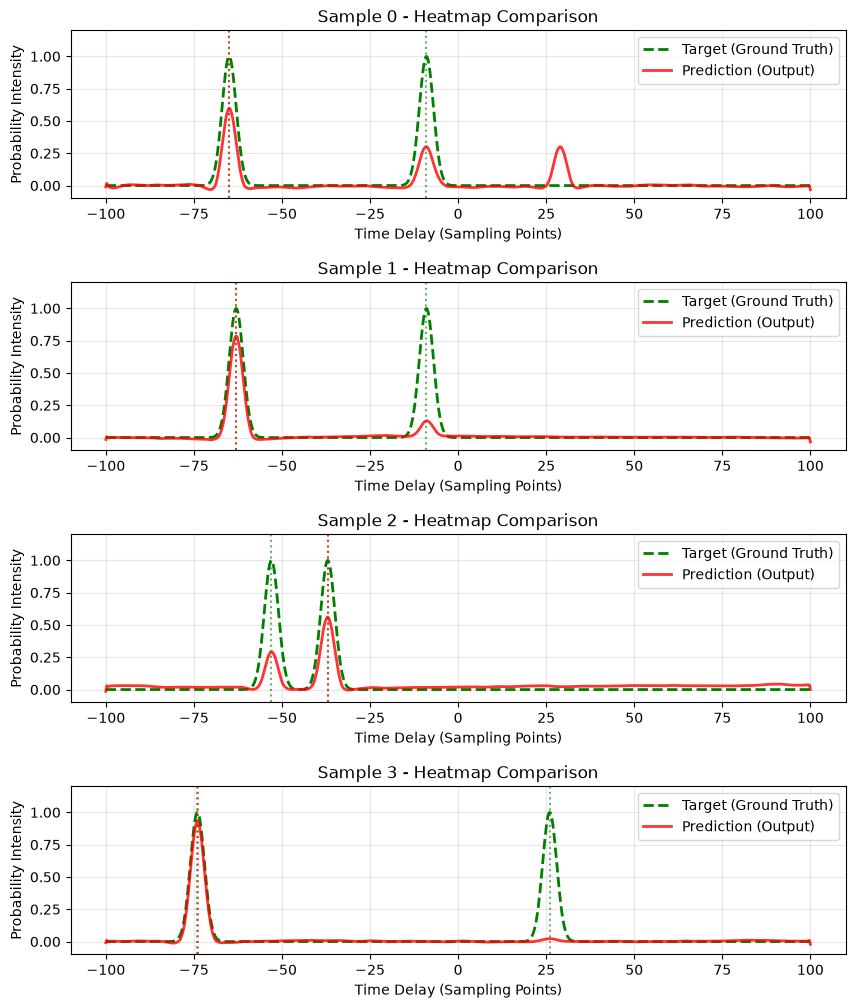

----------------------------------------


Epoch 15/20 [Train]:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 15/20 [Test] :   0%|          | 0/32 [00:00<?, ?it/s]

>> Epoch 15 Summary | Train Loss: 0.6956 | Test Loss: 0.4741



Epoch 16/20 [Train]:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 16/20 [Test] :   0%|          | 0/32 [00:00<?, ?it/s]

>> Epoch 16 Summary | Train Loss: 0.6301 | Test Loss: 0.8155

torch.Size([4, 801])
torch.Size([4, 801])
验证批次时延预测结果:
  样本 0:
    真实时延 : ['-29.00', '69.00']
    预测时延 : ['69.00']
  样本 1:
    真实时延 : ['-26.00', '-7.00']
    预测时延 : ['-25.97']
  样本 2:
    真实时延 : ['31.00', '66.00']
    预测时延 : ['30.91']
  样本 3:
    真实时延 : ['28.00', '68.00']
    预测时延 : ['27.93']


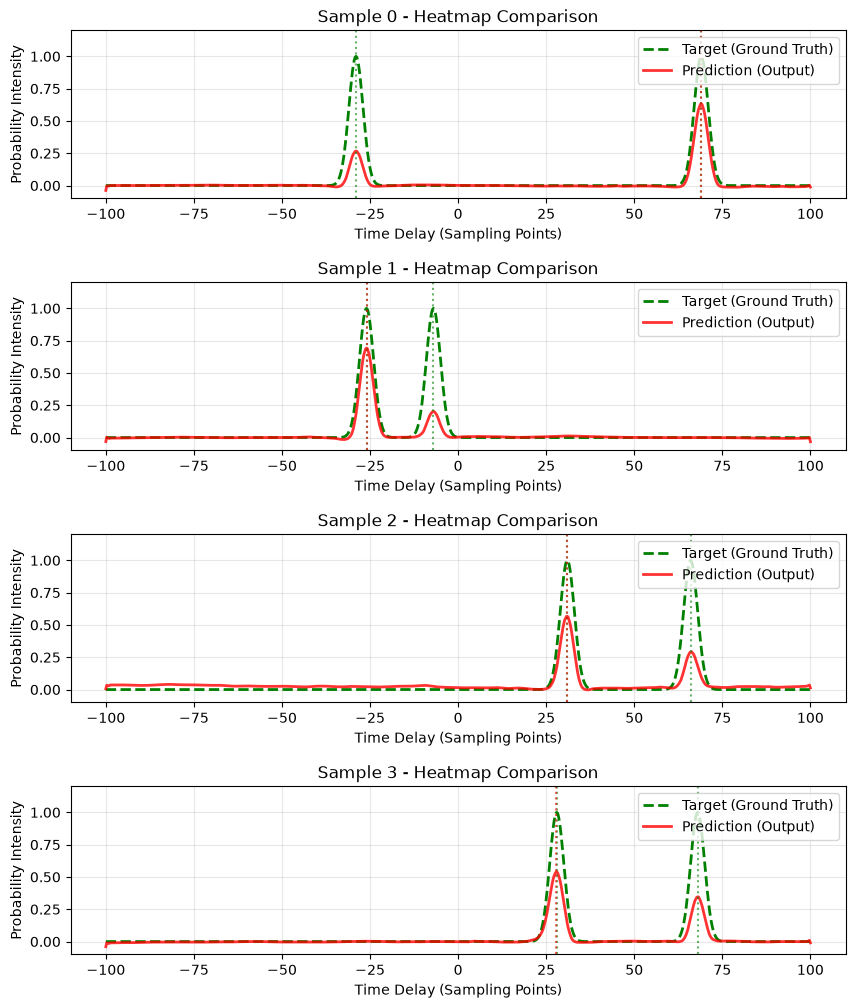

----------------------------------------


Epoch 17/20 [Train]:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 17/20 [Test] :   0%|          | 0/32 [00:00<?, ?it/s]

>> Epoch 17 Summary | Train Loss: 0.6422 | Test Loss: 0.4003



Epoch 18/20 [Train]:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 18/20 [Test] :   0%|          | 0/32 [00:00<?, ?it/s]

>> Epoch 18 Summary | Train Loss: 0.5980 | Test Loss: 0.5319

torch.Size([4, 801])
torch.Size([4, 801])
验证批次时延预测结果:
  样本 0:
    真实时延 : ['-17.00', '39.00']
    预测时延 : ['-16.99']
  样本 1:
    真实时延 : ['-24.00', '45.00']
    预测时延 : ['44.98']
  样本 2:
    真实时延 : ['-39.00', '81.00']
    预测时延 : ['81.03']
  样本 3:
    真实时延 : ['-66.00', '-39.00']
    预测时延 : ['-39.01']


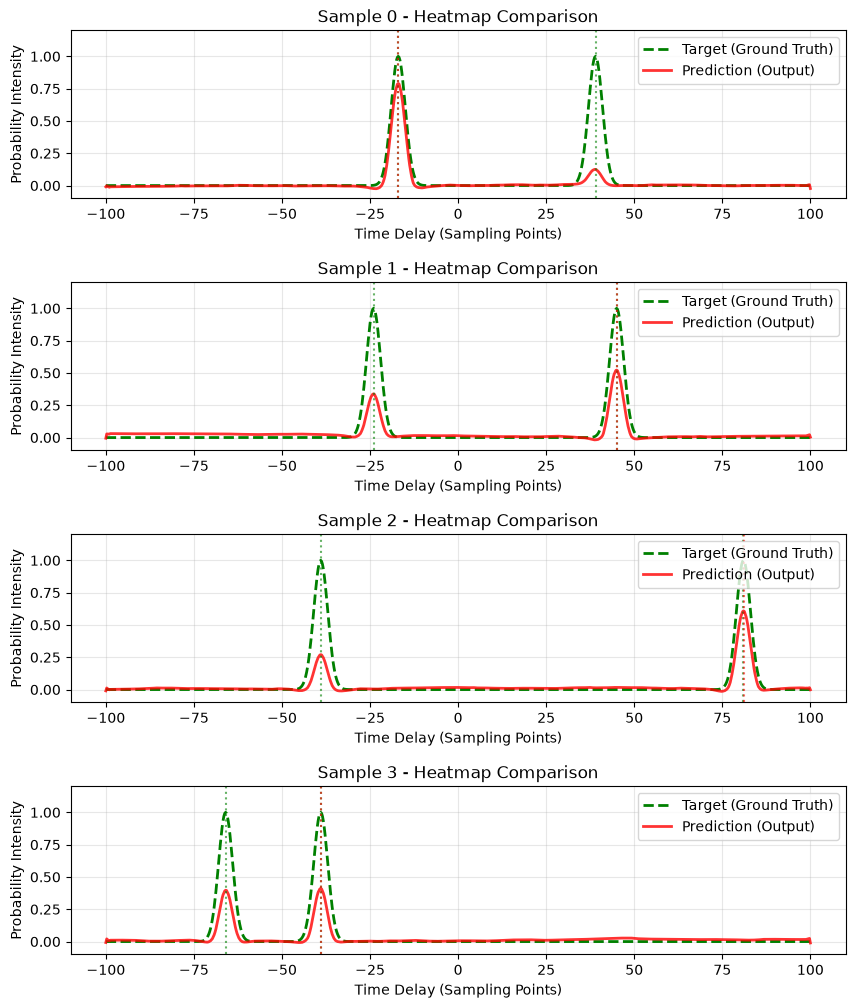

----------------------------------------


Epoch 19/20 [Train]:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 19/20 [Test] :   0%|          | 0/32 [00:00<?, ?it/s]

>> Epoch 19 Summary | Train Loss: 0.5437 | Test Loss: 0.3618



Epoch 20/20 [Train]:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 20/20 [Test] :   0%|          | 0/32 [00:00<?, ?it/s]

>> Epoch 20 Summary | Train Loss: 0.5901 | Test Loss: 0.5176

torch.Size([4, 801])
torch.Size([4, 801])
验证批次时延预测结果:
  样本 0:
    真实时延 : ['11.00', '34.00']
    预测时延 : ['11.05']
  样本 1:
    真实时延 : ['-57.00', '-18.00']
    预测时延 : ['-17.97']
  样本 2:
    真实时延 : ['30.00', '32.00']
    预测时延 : ['30.32']
  样本 3:
    真实时延 : ['-35.00', '74.00']
    预测时延 : ['74.01']


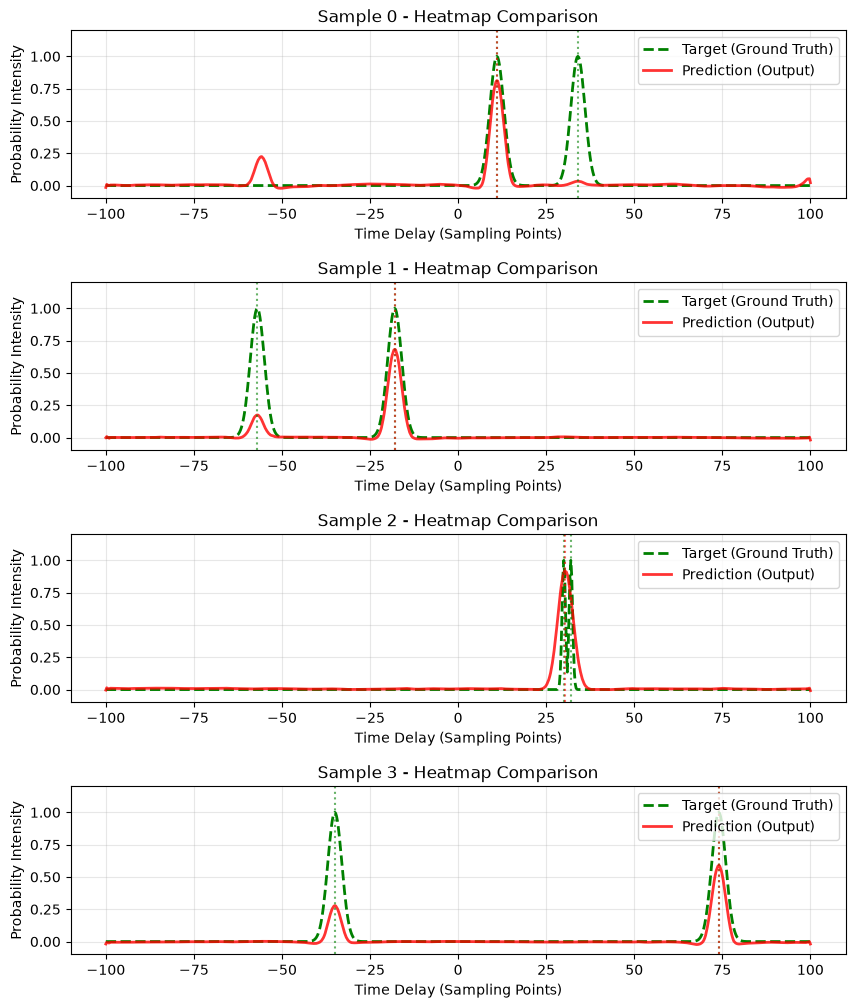

----------------------------------------


In [4]:

if __name__ == "__main__":
    path = train_and_validate(20)
    # continue_training(path,40)
    # inputs, targets = generate_simulation_data(32, 4000, 100)
    # print(inputs[1,0:1,:])
    # plt.plot(np.arange(1,4001),inputs[2,0:1,:].squeeze())
    # pass